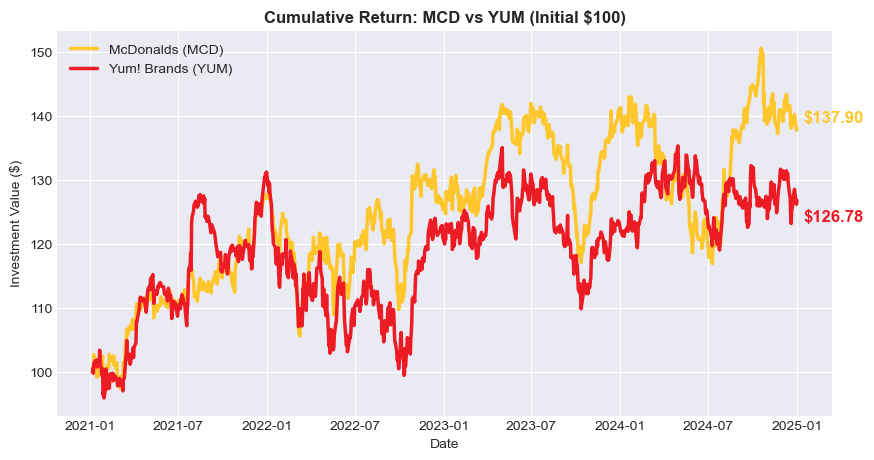

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# 1. read and analyse data
df_raw = pd.read_csv('fastfood_data.csv.csv')
df_raw.columns = df_raw.columns.str.upper()
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])
df_raw['PRC'] = df_raw['PRC'].abs()

df_close = df_raw.pivot(index='DATE', columns='TICKER', values='PRC').dropna()
daily_returns = df_close.pct_change().dropna()
cumulative_returns = (1 + daily_returns).cumprod() * 100

# 2. extract the data
last_date = cumulative_returns.index[-1]
mcd_final_value = cumulative_returns['MCD'].iloc[-1]
yum_final_value = cumulative_returns['YUM'].iloc[-1]

# 3. start drawing
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

# draw two lines
ax.plot(cumulative_returns.index, cumulative_returns['MCD'], label='McDonalds (MCD)', color='#FFC72C', linewidth=2.5)
ax.plot(cumulative_returns.index, cumulative_returns['YUM'], label='Yum! Brands (YUM)', color='#ED1C24', linewidth=2.5)

# add tag
ax.annotate(f'${mcd_final_value:.2f}', 
            xy=(last_date, mcd_final_value), 
            xytext=(5, 5), textcoords='offset points', 
            color='#FFC72C', fontweight='bold', fontsize=12)

ax.annotate(f'${yum_final_value:.2f}', 
            xy=(last_date, yum_final_value), 
            xytext=(5, -15), textcoords='offset points', 
            color='#ED1C24', fontweight='bold', fontsize=12)

# add title and legend
ax.set_title("Cumulative Return: MCD vs YUM (Initial $100)", fontweight='bold')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Investment Value ($)', fontsize=10)
ax.legend()

plt.show()

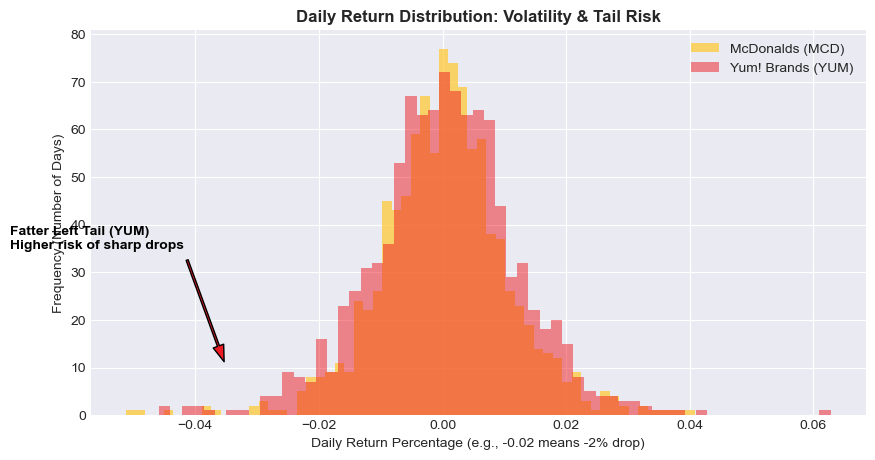

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Suppress warnings and set chart style
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. Load and Process Data
# ==========================================
df_raw = pd.read_csv('fastfood_data.csv.csv')
df_raw.columns = df_raw.columns.str.upper()
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])
df_raw['PRC'] = df_raw['PRC'].abs()

# Pivot table to get closing prices side-by-side
df_close = df_raw.pivot(index='DATE', columns='TICKER', values='PRC').dropna()

# Calculate daily returns (percentage change) for risk analysis
daily_returns = df_close.pct_change().dropna()

# ==========================================
# 2. Plot the Histogram (Distribution)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

# Plot MCD histogram (Yellow, less transparent)
ax.hist(daily_returns['MCD'], bins=60, alpha=0.7, label='McDonalds (MCD)', color='#FFC72C')

# Plot YUM histogram (Red, more transparent to show overlapping areas)
ax.hist(daily_returns['YUM'], bins=60, alpha=0.5, label='Yum! Brands (YUM)', color='#ED1C24')

# ==========================================
# 3. Add Annotation for "Fatter Left Tail"
# ==========================================
# This arrow visually proves your point about YUM's higher crash risk
ax.annotate('Fatter Left Tail (YUM)\nHigher risk of sharp drops', 
            xy=(-0.035, 10),              # Pointing to the negative return tail
            xytext=(-0.07, 35),           # Location of the text
            arrowprops=dict(facecolor='#ED1C24', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10, color='black', fontweight='bold')

# ==========================================
# 4. Formatting and Labels
# ==========================================
ax.set_title("Daily Return Distribution: Volatility & Tail Risk", fontweight='bold')
ax.set_xlabel('Daily Return Percentage (e.g., -0.02 means -2% drop)', fontsize=10)
ax.set_ylabel('Frequency (Number of Days)', fontsize=10)
ax.legend()

# Display the chart in Jupyter
plt.show()

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Suppress warnings and set chart style for a professional look
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. Page Configuration
# ==========================================
# Set the layout to wide mode for better visual experience
st.set_page_config(page_title="MCD vs YUM Analysis", layout="wide")

# ==========================================
# 2. Data Loading & Processing Function
# ==========================================
# Use @st.cache_data to prevent reloading data every time a button is clicked
@st.cache_data
def load_and_process_data():
    # Load the raw dataset (Make sure your filename is correct here)
    df_raw = pd.read_csv('fastfood_data.csv.csv')
    
    # Standardize column names to uppercase
    df_raw.columns = df_raw.columns.str.upper()
    
    # Convert DATE column to datetime format
    df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])
    
    # Clean the price data (convert negative prices to absolute values if any)
    if 'PRC' in df_raw.columns:
        df_raw['PRC'] = df_raw['PRC'].abs()
        
    # Pivot the table from long to wide format for easy comparison
    df_close = df_raw.pivot(index='DATE', columns='TICKER', values='PRC').dropna()
    
    # Calculate daily returns (Insight 2)
    daily_returns = df_close.pct_change().dropna()
    
    # Calculate cumulative returns based on a $100 initial investment (Insight 1)
    cumulative_returns = (1 + daily_returns).cumprod() * 100
    
    return df_close, daily_returns, cumulative_returns

# Execute the function to get processed data
df_close, daily_returns, cumulative_returns = load_and_process_data()

# Extract the final day's data for dynamic annotations
last_date = cumulative_returns.index[-1]
mcd_final_value = cumulative_returns['MCD'].iloc[-1]
yum_final_value = cumulative_returns['YUM'].iloc[-1]
mcd_return_pct = (mcd_final_value - 100) / 100
yum_return_pct = (yum_final_value - 100) / 100

# ==========================================
# 3. Sidebar Navigation
# ==========================================
st.sidebar.title("🍔 Fast Food Wars")
st.sidebar.markdown("---")
menu = st.sidebar.radio(
    "📊 Navigation Menu",
    ["🏠 1. Overview & Data Source", 
     "📈 2. Insight 1: Return Analysis", 
     "⚖️ 3. Insight 2: Volatility & Tail Risk", 
     "💻 4. Conclusion & Limitations"]
)
st.sidebar.markdown("---")
st.sidebar.caption("Data Source: CRSP Database")

# ==========================================
# 4. Page Routing Logic
# ==========================================

# ----------------- MENU 1 -----------------
if menu == "🏠 1. Overview & Data Source":
    st.title("Historical Price Performance & Risk Profile: MCD vs. YUM")
    st.markdown("---")
    
    col1, col2 = st.columns([5, 5])
    
    with col1:
        st.subheader("🎯 Project Objective")
        st.write("""
        This project compares the historical return performance and price volatility of **McDonald's (MCD)** and **Yum! Brands (YUM)**. 
        The goal is to help ordinary investors understand the risk-return trade-offs of both companies and determine which stock has historically been a more stable, defensive asset.
        """)
        
        st.subheader("📚 Data Source Declaration")
        st.info("This project utilizes historical stock data from the **CRSP (Center for Research in Security Prices)**, a premier academic database used by business schools worldwide.")
        
    with col2:
        st.subheader("⚙️ Selected Variables")
        st.markdown("""
        Data is extracted from the CRSP **Daily Stock File**. To minimize noise, we strictly focus on three core variables:
        *   📅 **DATE**: The trading date.
        *   🏷️ **TICKER**: The company ticker symbol (MCD or YUM).
        *   💵 **PRC**: The daily closing price.
        """)

# ----------------- MENU 2 -----------------
elif menu == "📈 2. Insight 1: Return Analysis":
    st.title("Insight 1: Cumulative Return Analysis")
    st.markdown("---")
    
    col1, col2 = st.columns([4, 6])
    
    with col1:
        st.subheader("📐 Methodology & Formulas")
        st.write("Since the two stocks have different starting share prices, we cannot compare their absolute prices directly. We standardized the initial investment to **$100** to calculate the cumulative return trajectory for a fair comparison.")
        
        # Render mathematical formulas using LaTeX
        st.latex(r"Value_t = \$100 \times \left( \frac{PRC_t}{PRC_0} \right)")
        
        st.markdown("**📝 Calculation Example (Based on our dataset):**")
        st.latex(rf"MCD\_Final = \$100 \times \dots = \${mcd_final_value:.2f}")
        st.latex(rf"YUM\_Final = \$100 \times \dots = \${yum_final_value:.2f}")
        
        st.subheader("🧠 Business Logic")
        st.success("""
        MCD's higher cumulative return partially reflects the stability of its **franchise-heavy business model**. It demonstrates stronger earnings resilience against inflation and market turbulence compared to traditional restaurant operations.
        """)
        
    with col2:
        st.subheader("📊 Cumulative Return Line Chart")
        
        # Generate the dynamic line chart
        fig1, ax1 = plt.subplots(figsize=(10, 5), dpi=100)
        ax1.plot(cumulative_returns.index, cumulative_returns['MCD'], label='McDonalds (MCD)', color='#FFC72C', linewidth=2.5)
        ax1.plot(cumulative_returns.index, cumulative_returns['YUM'], label='Yum! Brands (YUM)', color='#ED1C24', linewidth=2.5)
        
        # 🔥 Dynamic Data Annotations at the end of the lines 🔥
        ax1.annotate(f'${mcd_final_value:.2f}', xy=(last_date, mcd_final_value), xytext=(5, 5), 
                     textcoords='offset points', color='#FFC72C', fontweight='bold', fontsize=12)
        ax1.annotate(f'${yum_final_value:.2f}', xy=(last_date, yum_final_value), xytext=(5, -15), 
                     textcoords='offset points', color='#ED1C24', fontweight='bold', fontsize=12)
        
        ax1.set_xlabel('Date', fontsize=10)
        ax1.set_ylabel('Investment Value ($)', fontsize=10)
        ax1.legend()
        
        # Render the chart in Streamlit
        st.pyplot(fig1)
        
        st.markdown("**Chart Interpretation:**")
        st.write("The yellow curve (MCD) consistently outperforms the red curve (YUM). Over the observation period, an initial $100 investment yielded:")
        
        # Dynamic Metric Cards
        col2_1, col2_2 = st.columns(2)
        col2_1.metric("MCD Final Value", f"${mcd_final_value:.2f}", f"{mcd_return_pct*100:.2f}%", delta_color="normal")
        col2_2.metric("YUM Final Value", f"${yum_final_value:.2f}", f"{yum_return_pct*100:.2f}%", delta_color="normal")
        
        st.write("📌 *Notably, after the market volatility phase in 2022, MCD stabilized and recovered much faster, widening the performance gap with YUM.*")

# ----------------- MENU 3 -----------------
elif menu == "⚖️ 3. Insight 2: Volatility & Tail Risk":
    st.title("Insight 2: Volatility & Tail Risk Analysis")
    st.markdown("---")
    
    col1, col2 = st.columns([4, 6])
    
    with col1:
        st.subheader("📐 Methodology & Formulas")
        st.write("In financial analysis, risk is often measured by the volatility of returns. We calculated the daily returns based on closing prices and plotted a histogram to observe the distribution.")
        st.latex(r"Daily\_Return_t = \frac{PRC_t - PRC_{t-1}}{PRC_{t-1}}")
        
        st.subheader("🧠 Business Logic")
        st.warning("""
        YUM's higher probability of severe daily drops may be attributed to its **multi-brand portfolio and heavier reliance on overseas markets**, making it more susceptible to external shocks like currency fluctuations and regional policies.
        """)
        
    with col2:
        st.subheader("📊 Daily Return Distribution Histogram")
        
        # Generate the dynamic histogram
        fig2, ax2 = plt.subplots(figsize=(10, 5), dpi=100)
        ax2.hist(daily_returns['MCD'], bins=60, alpha=0.7, label='McDonalds', color='#FFC72C')
        ax2.hist(daily_returns['YUM'], bins=60, alpha=0.5, label='Yum! Brands', color='#ED1C24')
        
        # 🔥 The "Fatter Left Tail" pointing arrow 🔥
        ax2.annotate('Fatter Left Tail (YUM)\nHigher risk of sharp drops', 
                     xy=(-0.035, 10), 
                     xytext=(-0.07, 35), 
                     arrowprops=dict(facecolor='#ED1C24', shrink=0.05, width=1.5, headwidth=8),
                     fontsize=10, color='black', fontweight='bold')
                     
        ax2.set_xlabel('Daily Return Percentage', fontsize=10)
        ax2.set_ylabel('Frequency (Days)', fontsize=10)
        ax2.legend()
        
        # Render the chart in Streamlit
        st.pyplot(fig2)
        
        st.markdown("**Chart Interpretation:**")
        st.write("""
        Both stocks exhibit a normal distribution centered near zero, which is characteristic of stable, large-cap blue-chip stocks with mild daily fluctuations.
        
        🚨 **Focusing on the left negative return tail (e.g., -0.02 to -0.04):**
        The red bars corresponding to YUM are noticeably taller. This indicates that YUM experienced single-day sharp declines more frequently, representing a **"fatter left-tail risk"**.
        """)

# ----------------- MENU 4 -----------------
elif menu == "💻 4. Conclusion & Limitations":
    st.title("Conclusion & Academic Limitations")
    st.markdown("---")
    
    st.subheader("🏆 Data-Driven Conclusion")
    st.success("""
    Based on historical returns and volatility, **MCD achieved a higher cumulative return while exhibiting lower tail risk (fewer sharp daily drops).** 
    
    Evaluating through the lens of **Risk-Adjusted Return**, MCD proved to be a more robust and defensive stock during the observation period.
    """)
    
    st.markdown("<br>", unsafe_allow_html=True)
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("⚠️ Limitations")
        st.error("""
        This project relies solely on daily price data from CRSP, which is **Market Data**. It does not incorporate corporate accounting information.
        
        Stock prices can be skewed by short-term market sentiment and do not fully capture the long-term intrinsic value of the company.
        """)
        
    with col2:
        st.subheader("🚀 Future Improvements")
        st.info("""
        Future iterations could bridge CRSP price data with the **Compustat financial database**. 
        
        By integrating fundamental metrics like **ROA (Return on Assets)** and **EBIT (Earnings Before Interest and Taxes)**, we could conduct a more comprehensive comparison combining both "Market Performance" and "Financial Health".
        """)

Overwriting app.py


In [11]:
import os
os.system('start cmd /k "streamlit run app.py"')

0